# Etapa 3 — Diagnóstico de Calidad de Datos (Data Quality)
## Grupo 6 — Wholesale Customers

En esta sección se realizará un diagnóstico exhaustivo de la calidad del dataset crudo obtenido mediante el pipeline de ingesta (`src/ingestion`). El objetivo es identificar problemas estructurales y estadísticos antes de pasar a limpieza y EDA, justificando cada decisión con evidencia y no aplicando transformaciones "a ciegas".

**Flujo de esta sección:**
1. Inspección general de estructura
2. Valores faltantes (explícitos y codificados)
3. Duplicados y consistencia de registros
4. Tipos de datos y cardinalidad
5. Valores extremos y datos imposibles
6. Skewness (Asimetría ) y correlación excesiva
7. Data Quality Gates automatizados

In [1]:
import json
from pathlib import Path

import pandas as pd

# --------------------------------------------------------------------
# Rutas — notebook ubicado en la raíz del repo
# --------------------------------------------------------------------
RAW_DIR = Path("../data/raw")

CSV_PATH = RAW_DIR / "wholesale_customers_raw.csv"
METADATA_PATH = RAW_DIR / "ingestion_metadata.json"

# --------------------------------------------------------------------
# Cargar metadata de la ingesta (para saber qué versión de datos usamos)
# --------------------------------------------------------------------
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    ingestion_metadata = json.load(f)

print("Fuente de datos usada:", ingestion_metadata["source_method"])
print("Versión de datos (data_version):", ingestion_metadata["data_version"])
print("Fecha de ingesta:", ingestion_metadata["ingestion_timestamp_utc"])
print("Checksum SHA-256:", ingestion_metadata["sha256_checksum"])

# --------------------------------------------------------------------
# Cargar el dataset crudo (el que produjo ingest.py, no un archivo suelto)
# --------------------------------------------------------------------
df_raw = pd.read_csv(CSV_PATH)

print(f"\nDataset cargado: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
df_raw.head()

Fuente de datos usada: ucimlrepo
Versión de datos (data_version): 20260901_043335
Fecha de ingesta: 2026-09-01T04:33:35.462853+00:00
Checksum SHA-256: 5a78ef075afed8c106ec08984f560eac6c2b83cb966747ba4dde9643269e0b31

Dataset cargado: 440 filas x 8 columnas


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region
0,2,12669,9656,7561,214,2674,1338,3
1,2,7057,9810,9568,1762,3293,1776,3
2,2,6353,8808,7684,2405,3516,7844,3
3,1,13265,1196,4221,6404,507,1788,3
4,2,22615,5410,7198,3915,1777,5185,3


### 3.1 Copia de trabajo e inspección general de estructura

Se trabajará sobre una copia del dataset (`df`) para preservar `df_raw` sin modificaciones, como referencia trazable del dato original ingresado por el pipeline.

Se revisará el tipo de dato de cada columna y las estadísticas descriptivas básicas. Adicionalmente, dado que `Channel` y `Region` están codificadas como enteros (1, 2, 3) y no como texto, se documenta explícitamente el significado de cada código, contrastando las frecuencias observadas contra las reportadas en la fuente oficial del dataset (UCI Machine Learning Repository), sin alterar los valores originales en el DataFrame.

In [2]:
df = df_raw.copy()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
 7   Region            440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0


In [4]:
# --------------------------------------------------------------------
# Diccionarios SOLO para documentación/verificación — no se aplican al df
# --------------------------------------------------------------------
channel_meaning = {1: "Horeca (Hotel/Restaurant/Café)", 2: "Retail"}
region_meaning = {1: "Lisbon", 2: "Oporto", 3: "Other Region"}

# Frecuencias esperadas según la ficha del dataset en UCI ML Repository
channel_esperado = {1: 298, 2: 142}
region_esperado = {1: 77, 2: 47, 3: 316}

print("=== CHANNEL ===")
conteo_channel = df["Channel"].value_counts().sort_index()
for codigo, conteo in conteo_channel.items():
    print(f"  {codigo} = {channel_meaning[codigo]:<35} | observado: {conteo:>4} | esperado (UCI): {channel_esperado[codigo]}")

print("\n=== REGION ===")
conteo_region = df["Region"].value_counts().sort_index()
for codigo, conteo in conteo_region.items():
    print(f"  {codigo} = {region_meaning[codigo]:<15} | observado: {conteo:>4} | esperado (UCI): {region_esperado[codigo]}")

=== CHANNEL ===
  1 = Horeca (Hotel/Restaurant/Café)      | observado:  298 | esperado (UCI): 298
  2 = Retail                              | observado:  142 | esperado (UCI): 142

=== REGION ===
  1 = Lisbon          | observado:   77 | esperado (UCI): 77
  2 = Oporto          | observado:   47 | esperado (UCI): 47
  3 = Other Region    | observado:  316 | esperado (UCI): 316


**¿Qué significa el resultado?**

La inspección general confirma que el dataset ingresado corresponde efectivamente a la versión oficial de Wholesale Customers y que no presenta problemas estructurales evidentes en esta primera revisión:

- **Estructura y tipos de dato:** las 440 filas y 8 columnas coinciden con lo documentado en UCI ML Repository. Todas las columnas son de tipo `int64`, sin ninguna marcada como `object` o `float`, lo cual descarta de entrada errores de parseo

- **Sin nulos en esta vista inicial:** el conteo de `Non-Null Count` es 440 en las 8 columnas, es decir, no hay valores nulos explícitos a nivel de estructura. Esto se validará con mayor detalle en la sección 3.2.

- **Escalas muy distintas entre variables de gasto:** al comparar las medias, se observa que `Fresh` (media ≈ 12,000) y `Grocery` (media ≈ 7,951) manejan magnitudes varias veces mayores que `Delicassen` (media ≈ 1,525) o `Detergents_Paper` (media ≈ 2,881). Esta diferencia de escala será relevante más adelante: cualquier algoritmo de clustering basado en distancias (como K-Means) requerirá estandarización previa, de lo contrario las variables de mayor magnitud dominarían el cálculo de distancia sin que eso refleje necesariamente mayor importancia real.

- **Dispersión alta (std cercana o superior a la media):** en casi todas las variables de gasto, la desviación estándar es similar o mayor que la media (por ejemplo, `Fresh`: media ≈ 12,000, std ≈ 12,647). Esto es un primer indicio de asimetría y de la presencia de valores extremos, que se cuantificará formalmente en la sección 3.5 y 3.6.

- **Verificación de Channel y Region:** las frecuencias observadas coinciden exactamente con las reportadas en la ficha oficial del dataset:
  - `Channel`: 298 registros con código 1 (Horeca) y 142 con código 2 (Retail).
  - `Region`: 77 registros con código 1 (Lisbon), 47 con código 2 (Oporto) y 316 con código 3 (Other Region).
  
Esta coincidencia exacta confirma dos cosas: primero, que el archivo `wholesale_customers_raw.csv` generado por el pipeline de ingesta corresponde efectivamente a la versión íntegra y sin alteraciones del dataset original; segundo, que la interpretación de los códigos numéricos (1/2 para Channel, 1/2/3 para Region) documentada en el diccionario de esta sección es correcta y puede usarse con confianza más adelante, cuando se contrasten los clusters resultantes contra estas variables como validación externa.

### 3.2 Valores faltantes

Se revisan valores nulos explícitos y se investiga si existen valores como 0 o negativos que pudieran representar datos faltantes codificados, dado que el gasto anual en una categoría teóricamente no debería ser negativo.

Un dataset "sin missing" según `.isna()` puede aun así contener codificaciones ocultas que distorsionarían el análisis si no se detectan.

In [5]:
cols_gasto = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

print("Missing values explícitos (NaN):")
print(df.isna().sum())

print("\nValores <= 0 por columna de gasto (posibles códigos de faltante o error):")
print((df[cols_gasto] <= 0).sum())

Missing values explícitos (NaN):
Channel             0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
Region              0
dtype: int64

Valores <= 0 por columna de gasto (posibles códigos de faltante o error):
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


No se detectan missing values explícitos ni evidencia de valores codificados como faltantes: el conteo de `NaN` es 0 en las 8 columnas, y ninguna variable de gasto presenta valores menores o iguales a cero, lo cual descarta la hipótesis de una codificación oculta. 

Esto confirma lo observado en la inspección general: el dataset crudo no requiere imputación de valores faltantes en esta etapa. Esta ausencia de missing values se incorporará como una de las Data Quality Gates, de modo que cualquier batch futuro que sí presente nulos sea detectado automáticamente.

### 3.3 Duplicados

Se identifican filas completamente duplicadas y también posibles duplicados parciales 
(mismo perfil de gasto pero con Channel/Region distintos, lo cual sería inconsistente).

Registros duplicados inflarían artificialmente ciertos perfiles de gasto durante el clustering, sesgando los centroides hacia esos puntos repetidos.

In [6]:
duplicados_totales = df.duplicated().sum()
print(f"Filas completamente duplicadas: {duplicados_totales} ({duplicados_totales/len(df):.2%})")

duplicados_por_gasto = df.duplicated(subset=cols_gasto).sum()
print(f"Filas con mismo perfil de gasto (posible duplicado parcial): {duplicados_por_gasto}")

Filas completamente duplicadas: 0 (0.00%)
Filas con mismo perfil de gasto (posible duplicado parcial): 0


No existen filas completamente duplicadas ni registros con un perfil de gasto idéntico entre sí (0 casos en ambas verificaciones). Esto significa que cada uno de los 440 clientes aporta información única al análisis, por lo que no hay riesgo de que un perfil repetido distorsione los centroides durante el clustering. Al igual que con los missing values, esta ausencia de duplicados se incorporará como una Data Quality Gate (duplicados_bajo_umbral), de modo que un batch futuro con duplicados reales sí sea detectado y bloqueado.

### 3.4 Tipos de datos y cardinalidad

Se verifica que Channel y Region tengan únicamente los valores esperados (cardinalidad baja y conocida, ya documentada en 3.1) y que las variables de gasto sean numéricas continuas sin valores fuera de rango lógico.

Una categoría inesperada (ej. un código de región no documentado) indicaría un problema de origen de datos o un cambio de esquema que el pipeline de ingesta debería capturar como alerta, no ignorar.

In [7]:
print("Cardinalidad observada vs. esperada:")
print(f"Channel — valores únicos: {sorted(df['Channel'].unique())} (esperado: {{1, 2}})")
print(f"Region  — valores únicos: {sorted(df['Region'].unique())} (esperado: {{1, 2, 3}})")

print("\nTipos de dato por columna:")
print(df.dtypes)

Cardinalidad observada vs. esperada:
Channel — valores únicos: [np.int64(1), np.int64(2)] (esperado: {1, 2})
Region  — valores únicos: [np.int64(1), np.int64(2), np.int64(3)] (esperado: {1, 2, 3})

Tipos de dato por columna:
Channel             int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
Region              int64
dtype: object


La cardinalidad observada coincide exactamente con la esperada: `Channel` únicamente toma los valores {1, 2} y `Region` únicamente {1, 2, 3}, sin categorías inesperadas que sugieran un cambio de esquema o un error de origen. Asimismo, las 8 columnas mantienen el tipo `int64`, consistente con lo observado en la inspección general. Esta verificación confirma que el dataset no requiere corrección de tipos ni normalización de categorías antes de continuar

### 3.5 Valores extremos y datos imposibles

Se visualiza la distribución de cada variable de gasto mediante boxplots y se cuantifican outliers usando el criterio de rango intercuartílico (IQR). Adicionalmente se verifica que no existan valores negativos (gasto negativo es imposible).

A diferencia de un error de captura, en este dataset los valores extremos suelen corresponder a clientes de alto volumen reales (ej. grandes hoteles). La decisión de tratarlos (winsorizar, transformar con log, o dejarlos) debe basarse en esta evidencia, no en eliminarlos por default.

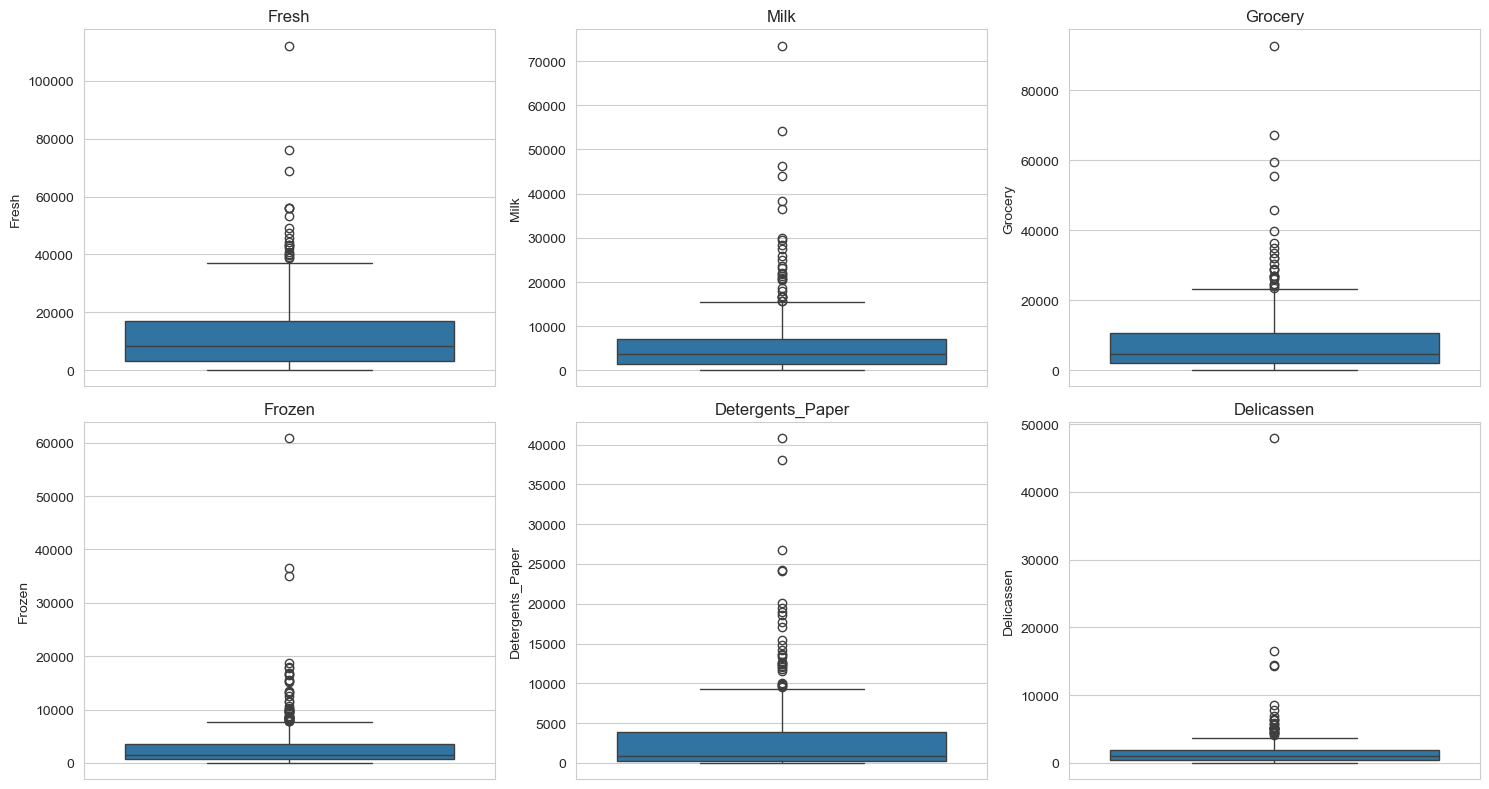

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cols_gasto):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [9]:
def contar_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return ((serie < limite_inferior) | (serie > limite_superior)).sum()

resumen_outliers = pd.Series({col: contar_outliers_iqr(df[col]) for col in cols_gasto})
resumen_outliers_pct = (resumen_outliers / len(df) * 100).round(1)

pd.DataFrame({"n_outliers": resumen_outliers, "pct": resumen_outliers_pct})

,n_outliers,pct
Fresh,20,4.5
Milk,28,6.4
Grocery,24,5.5
Frozen,43,9.8
Detergents_Paper,30,6.8
Delicassen,27,6.1


**¿Qué significa el resultado?**

Los boxplots muestran un patrón consistente en las seis variables de gasto: una caja compacta cercana a cero (mediana baja) acompañada de una cola larga de valores altos, sin observarse ningún punto por debajo de cero. Esto confirma que no hay valores negativos ni datos imposibles, y que los "outliers" detectados por el criterio de IQR corresponden a clientes de alto volumen de compra, no a errores de captura.

El conteo por IQR refuerza esta lectura:

- **Frozen** es la variable con mayor proporción de outliers (9.8%), seguida de **Detergents_Paper** (6.8%) y **Milk** (6.4%).
- **Fresh**, pese a tener el valor máximo absoluto más alto del dataset (112,151), es la variable con menor proporción de outliers (4.5%), lo que indica que su dispersión, aunque grande, está más distribuida a lo largo del rango y no concentrada en unos pocos extremos aislados.
- En conjunto, entre 4.5% y 9.8% de los clientes por variable se comportan como compradores de alto volumen, un porcentaje demasiado alto y consistente entre variables como para tratarlo como error; se interpreta como una característica real del negocio (existencia de clientes tipo "gran comprador", probablemente hoteles o cadenas grandes dentro del canal Horeca).

**Decisión derivada:** dado que estos valores son legítimos y no errores, no se eliminarán filas. Se evaluará en las siguientes etapas aplicar una transformación logarítmica sobre las variables de gasto (ver sección 3.6) en lugar de winsorizar, para preservar la información de estos clientes de alto  volumen sin que dominen por completo el cálculo de distancias en el clustering.

### 3.6 Skewness y correlación excesiva

Se calcula el sesgo (skewness) de cada variable de gasto y se construye una matriz de correlación entre ellas.

Un sesgo alto sugiere que conviene aplicar una transformación (log, por ejemplo) antes de clusterizar con algoritmos sensibles a la escala y distribución, como K-Means. 

Una correlación excesiva entre variables es evidencia de redundancia que podría justificar una reducción de dimensionalidad (PCA) más adelante.

In [10]:
print("Skewness por variable:")
print(df[cols_gasto].skew().sort_values(ascending=False))

Skewness por variable:
Delicassen          11.151586
Frozen               5.907986
Milk                 4.053755
Detergents_Paper     3.631851
Grocery              3.587429
Fresh                2.561323
dtype: float64


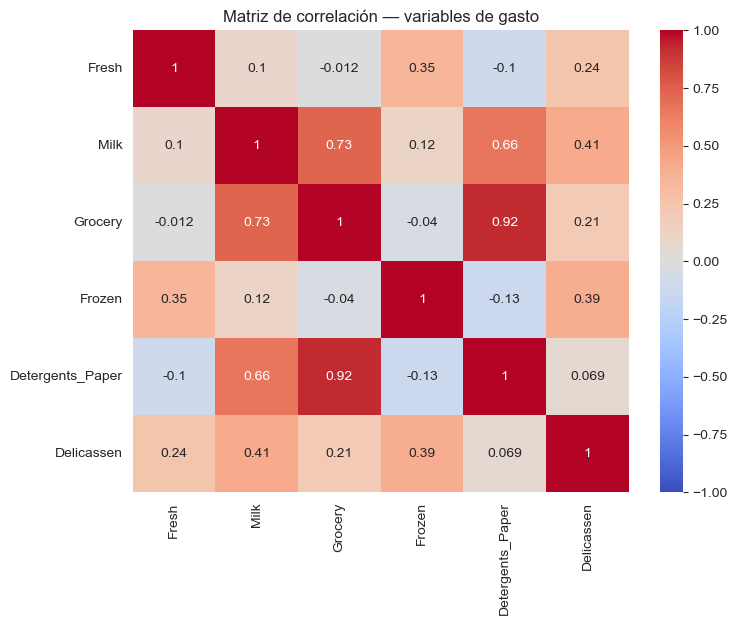

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_gasto].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación — variables de gasto")
plt.show()

El sesgo (skewness) es alto en las seis variables, todas muy por encima del umbral de referencia de 1 en 
valor absoluto:

- **Delicassen** presenta el sesgo más extremo (11.15), seguida de **Frozen** (5.91) y **Milk** (4.05).
- Incluso la variable con menor sesgo, **Fresh** (2.56), está muy por encima de lo que se consideraría una distribución razonablemente simétrica.

Este resultado es consistente con lo observado en los boxplots: distribuciones concentradas en valores bajos con colas largas hacia la derecha. Confirma que aplicar un algoritmo de clustering como K-Means directamente sobre estas variables, sin transformación, generaría centroides dominados por los pocos clientes de gasto extremadamente alto.

Respecto a la matriz de correlación:

- **Grocery y Detergents_Paper** presentan una correlación muy alta (0.92), la más fuerte del dataset. Esto tiene sentido de negocio: los clientes que compran grandes volúmenes de abarrotes probablemente también compran grandes volúmenes de detergentes y papel (ambos asociados a comercio minorista/retail).
- **Milk** también correlaciona fuertemente con **Grocery** (0.73) y **Detergents_Paper** (0.66), formando un grupo de tres variables con alta redundancia entre sí.
- El resto de las correlaciones son bajas o cercanas a cero (por ejemplo, Fresh–Grocery: -0.012), lo que indica que **Fresh**, **Frozen** y **Delicassen** aportan información relativamente independiente respecto al grupo Milk–Grocery–Detergents_Paper.

**Decisión derivada:** la combinación de sesgo alto + correlación excesiva entre Grocery, Detergents_Paper y Milk justifica dos acciones para las siguientes etapas: 
- 1. Aplicar transformación logarítmica a las seis variables de gasto para reducir el sesgo.
- 2. Evaluar PCA o selección de variables para atenuar la redundancia del grupo Grocery–Detergents_Paper–Milk antes de clusterizar, evitando que este grupo correlacionado tenga un peso implícito mayor en el cálculo de distancias.

### 4. Data Quality Gates
Se implementan reglas de validación automatizadas que el pipeline debería ejecutar antes de permitir que los datos avancen a la etapa de entrenamiento.

Estas reglas son la base del componente "DATA VALIDATION → PASS/FAIL → ALERT" exigido en la arquitectura MLOps del proyecto. 

Es importante notar que los umbrales (por ejemplo, 2% de duplicados) no se calibran para que el dataset actual "raspe" el límite, sino para validar de forma robusta cualquier batch futuro: el umbral debe ser lo bastante estricto para detectar un problema real, pero con tolerancia suficiente para no generar falsos positivos ante coincidencias legítimas. El hecho de que el dataset crudo actual tenga 0% de duplicados no significa que la regla deba fijarse en 0%; significa que el dataset actual pasa la regla con margen.

La regla de volumen mínimo (`min_rows`) se basa en un porcentaje del tamaño conocido del dataset (440 registros). El diagnóstico de calidad no encontró duplicados (0%) y los outliers detectados por columna se ubican entre 4.5% y 9.8%, un nivel moderado que se tratará mediante posible transformación en la etapa de limpieza, no mediante eliminación de filas. Dado que no se espera una reducción sustancial del volumen de datos bajo el tratamiento planeado, se definió un umbral del 90% (396 filas) — un margen de 10% suficiente para absorber ajustes menores futuros, pero lo bastante estricto para detectar una pérdida de datos real en el pipeline.

In [12]:
# Tamaño histórico de referencia del dataset (UCI Wholesale Customers)
N_FILAS_HISTORICO = 440
TOLERANCIA_MIN_FILAS = 0.9  # se acepta hasta un 10% menos que el histórico


def validar_calidad_datos(data: pd.DataFrame, cols_gasto: list) -> dict:
    """
    Ejecuta las Data Quality Gates sobre un DataFrame de Wholesale Customers.
    Devuelve un diccionario con el resultado (PASS/FAIL) de cada regla.
    """
    resultados = {}

    min_filas_esperadas = int(TOLERANCIA_MIN_FILAS * N_FILAS_HISTORICO)
    resultados["min_rows"] = {
        "pass": len(data) >= min_filas_esperadas,
        "detalle": f"{len(data)} filas (esperado: ≥ {min_filas_esperadas}, {int(TOLERANCIA_MIN_FILAS*100)}% del histórico)"
    }

    columnas_obligatorias = cols_gasto + ["Channel", "Region"]
    nulos = data[columnas_obligatorias].isna().sum().sum()
    resultados["sin_nulos_obligatorios"] = {
        "pass": nulos == 0,
        "detalle": f"{nulos} valores nulos en columnas obligatorias"
    }

    prop_duplicados = data.duplicated().mean()
    resultados["duplicados_bajo_umbral"] = {
        "pass": prop_duplicados < 0.02,
        "detalle": f"{prop_duplicados:.2%} de filas duplicadas (umbral: 2%)"
    }

    # Regla adicional: tipos numericos validos
    columnas_no_numericas = [c for c in cols_gasto if not pd.api.types.is_numeric_dtype(data[c])]
    resultados["tipos_numericos_validos"] = {
        "pass": len(columnas_no_numericas) == 0,
        "detalle": (
            f"Columnas con tipo no numerico: {columnas_no_numericas}"
            if columnas_no_numericas else "Todas las columnas de gasto son numericas"
        )
    }

    negativos = (data[cols_gasto] < 0).sum().sum()
    resultados["sin_gastos_negativos"] = {
        "pass": negativos == 0,
        "detalle": f"{negativos} valores negativos en variables de gasto"
    }

    channel_valido = set(data["Channel"].unique()).issubset({1, 2})
    region_valida = set(data["Region"].unique()).issubset({1, 2, 3})
    resultados["cardinalidad_categorica_valida"] = {
        "pass": channel_valido and region_valida,
        "detalle": f"Channel válido: {channel_valido}, Region válido: {region_valida}"
    }

    # Regla adicional: esquema sin columnas inesperadas
    columnas_esperadas = set(cols_gasto + ["Channel", "Region"])
    columnas_extra = set(data.columns) - columnas_esperadas
    resultados["esquema_sin_columnas_extra"] = {
        "pass": len(columnas_extra) == 0,
        "detalle": (
            f"Columnas inesperadas: {sorted(columnas_extra)}"
            if columnas_extra else "Sin columnas fuera del esquema esperado"
        )
    }

    return resultados


reporte = validar_calidad_datos(df, cols_gasto)

for regla, resultado in reporte.items():
    estado = "✅ PASS" if resultado["pass"] else "❌ FAIL"
    print(f"{estado} | {regla}: {resultado['detalle']}")

todas_pasaron = all(r["pass"] for r in reporte.values())
print(f"\nResultado global: {'PASS ✅' if todas_pasaron else 'FAIL ❌ — revisar reglas marcadas arriba'}")

✅ PASS | min_rows: 440 filas (esperado: ≥ 396, 90% del histórico)
✅ PASS | sin_nulos_obligatorios: 0 valores nulos en columnas obligatorias
✅ PASS | duplicados_bajo_umbral: 0.00% de filas duplicadas (umbral: 2%)
✅ PASS | tipos_numericos_validos: Todas las columnas de gasto son numericas
✅ PASS | sin_gastos_negativos: 0 valores negativos en variables de gasto
✅ PASS | cardinalidad_categorica_valida: Channel válido: True, Region válido: True
✅ PASS | esquema_sin_columnas_extra: Sin columnas fuera del esquema esperado

Resultado global: PASS ✅


### Conclusiones del diagnóstico de calidad

- **Significado de variables categóricas:** confirmado — Channel (1=Horeca, 2=Retail), Region (1=Lisbon, 2=Oporto, 3=Other Region); las frecuencias observadas coinciden exactamente con la fuente oficial (UCI ML Repository), validando la integridad del dataset ingresado.
- **Missing values:** no se detectaron valores nulos explícitos ni codificados (0 casos en ambas verificaciones); no se requiere imputación.
- **Duplicados:** no existen filas duplicadas ni perfiles de gasto repetidos (0 casos); no se requiere deduplicación.
- **Tipos y cardinalidad:** correctos en las 8 columnas; Channel y Region no presentan categorías inesperadas.
- **Outliers:** presentes en las seis variables de gasto (entre 4.5% y 9.8% según variable, mayor concentración en Frozen), pero corresponden a clientes reales de alto volumen de compra, no a errores. Se conservan; se aplicará transformación logarítmica en lugar de eliminarlos o winsorizarlos.
- **Sesgo (skewness):** alto en las seis variables (rango: 2.56 en Fresh hasta 11.15 en Delicassen), consistente con la presencia de outliers legítimos. Todas las variables son candidatas a transformación logarítmica antes del clustering.
- **Correlación:** redundancia relevante entre Grocery, Detergents_Paper (0.92) y Milk (0.73 con Grocery, 0.66 con Detergents_Paper). Se evaluará PCA o selección de variables para reducir esta redundancia.
- **Data Quality Gates:** las siete reglas automatizadas (mínimo de filas, sin nulos obligatorios, duplicados bajo umbral, tipos numéricos válidos, sin gastos negativos, cardinalidad categórica válida, esquema sin columnas extra) pasaron sobre el dataset crudo.

## Resumen de decisiones tomadas en esta etapa

| Hallazgo | Decisión | Dónde se implementa |
|---|---|---|
| Skewness (Asimetría) alto en las 6 variables de gasto (rango: 2.56–11.15) | Log-transform (log1p) antes del clustering | `FeatureBuilder._log_transform` |
| Outliers presentes (4.5%–9.8% por variable) pero son clientes reales | No se eliminan; se comprimen con log-transform | `FeatureBuilder._log_transform` |
| Correlación excesiva entre Grocery, Detergents_Paper (0.92) y Milk (0.73) | Reducir redundancia con PCA | `FeatureBuilder(n_pca_components=5)` |
| Sin nulos, duplicados ni valores negativos | No se requiere imputación ni deduplicación | Directo a Feature Engineering |
| Data Quality Gates: 7/7 reglas PASS | Proceder a etapa de Feature Engineering | `src/data_quality/validate.py` |

**Siguiente etapa:** `notebooks/02_eda_feature_engineering.ipynb` (EDA e Ingeniería de Features)